In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from typing import Optional, Type, Union
from scipy.interpolate import CubicSpline
import time
import warnings

#few imports
from few.trajectory.inspiral import EMRIInspiral #function to generate trajectories
from few.trajectory.ode.base import ODEBase #superclass for defining modified flux trajectories
from few.trajectory.ode.flux import KerrEccEqFlux #Adiabatic KerrEccEq base trajectory class

from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum
from few.utils.modeselector import ModeSelector

from few.waveform import (
    FastSchwarzschildEccentricFlux, 
    SlowSchwarzschildEccentricFlux, 
    Pn5AAKWaveform,
    FastKerrEccentricEquatorialFlux,
    GenerateEMRIWaveform
)

from few.waveform.base import SphericalHarmonicWaveformBase #generic waveform generation class
from few.utils.baseclasses import SphericalHarmonic, KerrEccentricEquatorial, ParallelModuleBase, BackendLike

from few.utils.constants import YRSID_SI

from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )

from few.trajectory.ode.SuperKludge02_support import (y0_func, y1_func, y2_func, es0_func, es1_func, es2_func, dpdt1PA_func, dedt1PA_func, dpdt2PA_func, dedt2PA_func, dEdtH1PA, dLdtH1PA) #direct flux calculations
from few.trajectory.ode.SuperKludge02_support import (dpdE, dpdL, dedE, dedL, dEdChi1, dLdChi1, dEdm1, dLdm1) #Jacobian calculations
#few data saved in: /home/shubham/.local/share/few/v2.0.0rc0.post1.dev9+g1e42973.d20250303/download

In [2]:
if False:
    from sympy.parsing.mathematica import parse_mathematica
    
    with open("/home/shubham/SuperKludge/version0.2/dLdtH.m", "r") as file:
        math_expr = file.read()
    
    sympy_expr = parse_mathematica(math_expr)
    #print(sympy_expr)

In [3]:
class SuperKludgeFlux(KerrEccEqFlux):
    """
    SuperKludgeFlux as a modification of the Kerr eccentric equatorial flux ODE.
    Additional parameters (in this order):
        chi2 (float) : dimensionless spin of the secondary.
        evolve_1PA (bool) : whether to include 1PA corrections.
        evolve_primary (bool) : whether to evolve MBH mass M and spin a/chi1.
        evolve_2PA (bool) : whether to include 2PA corrections.
    """

    def add_fixed_parameters(self, m1: float, m2: float, a: float, additional_args = None):

        #print("additional args: ", additional_args)

        #this is where we initialize additional args like chi2, massratio, flags for 1PA, 2PA, and primary evolution.
        #expected order: addiational_args = [chi2, 1PA_flag, evolve_primary_flag, 2PA_flag]
        
        self.massratio = m1 * m2 / (m1 + m2) ** 2
        self.m1 = m1
        
        self.a = a
        self.chi2 = additional_args[0] #secondary spin (dimless)

        try:
            self.evolve_1PA = bool(additional_args[1]) #whether to include 1PA corrections.
        except IndexError:
            self.evolve_1PA = True #defaults to True
            
        try:
            self.evolve_primary = bool(additional_args[2]) #whether to evolve \delta~M, \delta~a. If False, just set delta_m1, delta_a = 0.0 throughout evolution.
            if self.evolve_primary:
                warnings.warn("Flux at horizon for primary evolution are PN-approximated and may be unsuitable.")
        except IndexError:
            self.evolve_primary = False #do not include primary evolution.

        try:
            self.evolve_2PA = bool(additional_args[3]) #whether to include 2PA corrections
        except IndexError:
            self.evolve_2PA = False #do not evolve 2PA terms
        
        if additional_args is None:
            self.num_add_args = 0
        else:
            self.num_add_args = len(additional_args)

    @property
    def nparams(self):
        """
        An integer describing the number of parameters this ODE will integrate.
        Defaults to 6 (three orbital elements, three orbital phases).
        """
        return 8 #[p, e, x, Phi_phi0, Phi_r, Phi_theta, delta_m1, delta_a]

    def evaluate_rhs(
        self, y: Union[list[float], np.ndarray]
    ) -> list[Union[float, np.ndarray]]:

        a_at_t = self.a + y[-1] #evolving spin
        
        if self.use_ELQ:
            E, L, Q = y[:3]
            p, e, x = ELQ_to_pex(a_at_t, E, L, Q)
        else:
            p, e, x = y[:3]

        Omega_phi, Omega_theta, Omega_r = get_fundamental_frequencies(a_at_t, p, e, x)

        Edot, Ldot = self.interpolate_flux_grids(p, e, x, a=a_at_t, pLSO=self.p_sep_cache)

        return [Edot, Ldot, 0.0, Omega_phi, Omega_theta, Omega_r, 0.0, 0.0] #we will add delta_m1_dot, delta_a_dot in modify_rhs

    def modify_rhs(
        self, ydot: np.ndarray, y: np.ndarray, **kwargs
    ) -> None:
        """
        This function allows the user to modify the right-hand side of the ODE after any required Jacobian transforms
        have been applied. Note: modification is in place.
        !!! m1 is the MBH mass in solar masses. TM is the total mass (m1 + m2) in solar masses.!!!
        """

        pdot, edot, _, Omega_phi, Omega_theta, Omega_r = ydot[:6]
        p, e = y[:2]

        delta_m1 = y[-2]
        delta_a = y[-1]
        delta_m1_dot = ydot[-2]
        delta_a_dot = ydot[-2]
        
        M_at_t = self.m1 + delta_m1 #this is how delta_m1 is defined TODO: Confirm scaling!!!
        a_at_t = self.a + delta_a #this is how delta_a is defined

        #evolution of MBH mass and spin
        if self.evolve_primary:
            
            #we will have Edot, Ldot at horizon as a function of p, e, x.
            #these are PN approximations at 1PA.
            EdotH = self.m1 * self.massratio**2 * dEdtH1PA(p, e, 1.0, a_at_t) #Energy flux at horizon, 1PA contribution, scaled by the MBH mass.
            LdotH = self.m1 ** 2 * self.massratio**2 * dLdtH1PA(p, e, 1.0, a_at_t) #Angular momentum flux at horizon, 1PA contribution, scaled by the MBH mass ** 2.

            #calculate delta_m1_dot, delta_a_dot as functions of EdotH, LdotH
            S1dot = - LdotH #should be positive.
            
            #print(S1dot)
            
            delta_m1_dot = - EdotH #same as M_dot
            delta_a_dot = - (2 * (a_at_t) * delta_m1_dot)/(M_at_t) + S1dot/(M_at_t)**2 #same as a_dot. S1dot should be positive.

            #print(EdotH, LdotH)#delta_m1, delta_m1_dot, delta_a, delta_a_dot)
                        
            #update ydot
            ydot[-2:] = [delta_m1_dot, delta_a_dot]
            
            #add contribution to pdot, edot due to delta_m1_dot, delta_a_dot
            pdot += ((dpdE(a_at_t, p, e, 1.0)*dEdChi1(a_at_t, p, e, 1.0) + dpdL(a_at_t, p, e, 1.0)*dLdChi1(a_at_t, p, e, 1.0))*delta_a_dot +
                    (dpdE(a_at_t, p, e, 1.0)*dEdm1(a_at_t, p, e, 1.0, M_at_t) + dpdL(a_at_t, p, e, 1.0)*dLdm1(a_at_t, p, e, 1.0, M_at_t))*delta_m1_dot)

            edot += ((dedE(a_at_t, p, e, 1.0)*dEdChi1(a_at_t, p, e, 1.0) + dedL(a_at_t, p, e, 1.0)*dLdChi1(a_at_t, p, e, 1.0))*delta_a_dot +
                    (dedE(a_at_t, p, e, 1.0)*dEdm1(a_at_t, p, e, 1.0, M_at_t) + dedL(a_at_t, p, e, 1.0)*dLdm1(a_at_t, p, e, 1.0, M_at_t))*delta_m1_dot)
            
        #calculating yPhi and Lambda for the PN-approximate PA contributions to pdot, edot
        yPhi = Omega_phi**(1/3)
        Lambda = 3. * (Omega_phi)**(2/3) * (Omega_phi/Omega_r - 1.)**(-1.)

        #PN parameters in terms of yPhi and Lambda
        yy0, y1, y2 = (y0_func(yPhi, Lambda), 
                      y1_func(yPhi, Lambda, a_at_t, self.chi2), 
                      y2_func(yPhi, Lambda, a_at_t, self.chi2))

        es0, es1, es2 = (es0_func(yPhi, Lambda, a_at_t),
                         es1_func(yPhi, Lambda, a_at_t, self.chi2),
                         es2_func(yPhi, Lambda, a_at_t, self.chi2))     

        if self.evolve_1PA:

            #adding 1PA corrections:
            pdot1PA = self.massratio**2 * dpdt1PA_func(yy0, y1, y2, es0, es1, es2, yPhi, Lambda, p, e, a_at_t, self.chi2)
            edot1PA = self.massratio**2 * dedt1PA_func(yy0, y1, y2, es0, es1, es2, yPhi, Lambda, p, e, a_at_t, self.chi2)
    
            pdot = pdot + pdot1PA
            edot = edot + edot1PA

        if self.evolve_2PA:

            #adding 2PA corrections:
            pdot2PA = self.massratio**3 * dpdt2PA_func(yy0, y1, y2, es0, es1, es2, yPhi, Lambda, p, e, a_at_t, self.chi2)
            edot2PA = self.massratio**3 * dedt2PA_func(yy0, y1, y2, es0, es1, es2, yPhi, Lambda, p, e, a_at_t, self.chi2)

            pdot = pdot + pdot2PA
            edot = edot + edot2PA
            
        ydot[0] = pdot 
        ydot[1] = edot

    def __call__(
        self,
        y: Union[list, np.ndarray],
        out: Optional[np.ndarray] = None,
        **kwargs: Optional[dict],
    ) -> np.ndarray:
        in_bounds = self.cache_values_and_check_bounds(y)

        if out is None:
            out = np.zeros(8) #8 params in SuperKludge (3 orbital params, 3 phases, 2 evolution of primary)
            
        if in_bounds:
            out[:] = self.evaluate_rhs(y, **kwargs)
        else:
            out *= np.nan

        self.modify_rhs_before_Jacobian(out, y, **kwargs)

        if self.apply_Jacobian_bool:  # implicitly this means that y contains (p, e, x)
            out[:2] = ELdot_to_PEdot_Jacobian(self.a + y[-1], *y[:3], *out[:2])

        self.modify_rhs(out, y, **kwargs)

        if self.integrate_backwards:
            out *= -1.

        return out

#waveform class
class SuperKludgeWaveform(SphericalHarmonicWaveformBase, KerrEccentricEquatorial):

    """ 
    waveform class definition similar to pre-built classes in few.waveform.waveform.
    Call using GenerateEMRIWaveform for detector frame.
    """
    
    def __init__(
        self,
        /,
        inspiral_kwargs: Optional[dict] = None,
        amplitude_kwargs: Optional[dict] = None,
        sum_kwargs: Optional[dict] = None,
        Ylm_kwargs: Optional[dict] = None,
        mode_selector_kwargs: Optional[dict] = None,
        force_backend: BackendLike = None,
        **kwargs: dict,
        ):
        if inspiral_kwargs is None:
            inspiral_kwargs = {}
        inspiral_kwargs["func"] = SuperKludgeFlux #SuperKludge Inspiral Class

        if sum_kwargs is None:
            sum_kwargs = {}
        mode_summation_module = InterpolatedModeSum
        if "output_type" in sum_kwargs:
            if sum_kwargs["output_type"] == "fd":
                mode_summation_module = FDInterpolatedModeSum

        if mode_selector_kwargs is None:
            mode_selector_kwargs = {}
        mode_selection_module = ModeSelector
        if "mode_selection_type" in mode_selector_kwargs:
            if mode_selector_kwargs["mode_selection_type"] == "neural":
                mode_selection_module = NeuralModeSelector
                if "mode_selector_location" not in mode_selector_kwargs:
                    mode_selector_kwargs["mode_selector_location"] = os.path.join(
                        dir_path,
                        "./files/modeselector_files/KerrEccentricEquatorialFlux/",
                    )
                mode_selector_kwargs["keep_inds"] = np.array(
                    [0, 1, 2, 3, 4, 6, 7, 8, 9]
                )

        KerrEccentricEquatorial.__init__(
            self,
            **{
                key: value
                for key, value in kwargs.items()
                if key in ["lmax", "nmax", "ndim"]
            },
            force_backend=force_backend,
        )
        SphericalHarmonicWaveformBase.__init__(
            self,
            inspiral_module=EMRIInspiral,
            amplitude_module=AmpInterpKerrEccEq,
            sum_module=mode_summation_module,
            mode_selector_module=mode_selection_module,
            inspiral_kwargs=inspiral_kwargs,
            amplitude_kwargs=amplitude_kwargs,
            sum_kwargs=sum_kwargs,
            Ylm_kwargs=Ylm_kwargs,
            mode_selector_kwargs=mode_selector_kwargs,
            **{
                key: value for key, value in kwargs.items() if key in ["normalize_amps"]
            },
            force_backend=force_backend,
        )

    @classmethod
    def supported_backends(cls):
        return cls.GPU_RECOMMENDED()

    @property
    def allow_batching(self):
        return False

    def __call__(
        self,
        m1: float,
        m2: float,
        a: float,
        p0: float,
        e0: float,
        xI: float,
        theta: float,
        phi: float,
        *args: Optional[tuple],
        **kwargs: Optional[dict],
    ) -> np.ndarray:
        """
        Generate the waveform.

        Args:
            m1: Mass of larger black hole in solar masses.
            m2: Mass of compact object in solar masses.
            a: Dimensionless spin of massive black hole.
            p0: Initial semilatus rectum of inspiral trajectory.
            e0: Initial eccentricity of inspiral trajectory.
            xI: Initial cosine of the inclination angle.
            theta: Polar angle of observer.
            phi: Azimuthal angle of observer.
            *args: Placeholder for additional arguments.
            **kwargs: Placeholder for additional keyword arguments.

        Returns:
            Complex array containing generated waveform.

        """
        return self._generate_waveform(
            m1,
            m2,
            a,
            p0,
            e0,
            xI,
            theta,
            phi,
            *args,
            **kwargs,
        )

In [4]:
#initializing trajectories
start = time.time()
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
print(time.time() - start)

start = time.time()
adiabatic_traj = EMRIInspiral(func=KerrEccEqFlux)
print(time.time() - start)

9.328969955444336
4.389810800552368


/tmp/ipykernel_26838/3122667515.py:31: UserWarning: Flux at horizon for primary evolution are PN-approximated and hence unsuitable for p <= 10.0.
  warnings.warn("Flux at horizon for primary evolution are PN-approximated and hence unsuitable for p <= 10.0.")


0.11909985542297363
0.08411622047424316


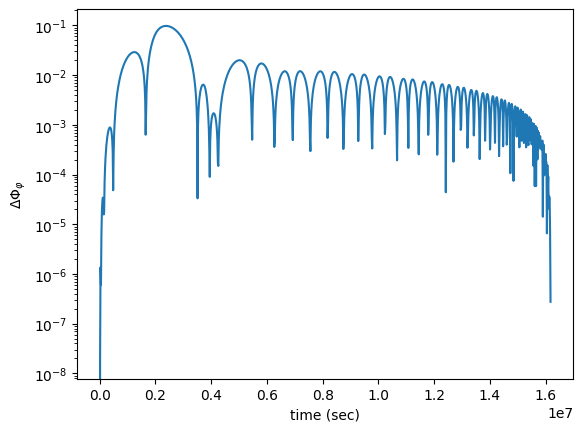

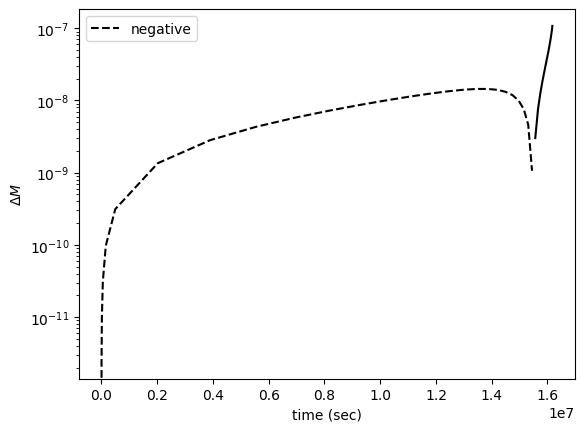

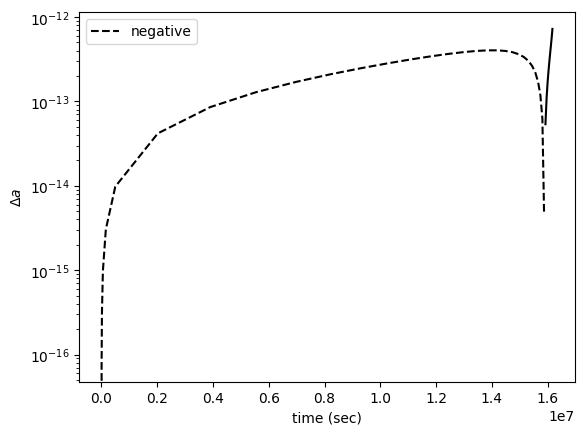

In [6]:
# define parameters
m1 = 1e6
m2 = 5e1
a = 0.5
e0 = 0.1 #must be non-zero.
p0 = 10.0
Y0 = 1.0
dist = 1.0
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/5.
phiK = np.pi/6.
Phi_phi0 = 0.
Phi_theta0 = 0.
Phi_r0 = 0.
dt = 10.0
T = 1.0

start = time.time()
chi2 = 0.1 #dimensionless secondary spin
evolve_1PA = False
evolve_primary = True
evolve_2PA = False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]
t1, p1, e1, x1, pp1, pt1, pr1, delta_M1, delta_a1 = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt)
print(time.time() - start)

start = time.time()
chi2 = 0.1 #dimensionless secondary spin
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]
t2, p2, e2, x2, pp2, pt2, pr2, delta_M2, delta_a2 = SK_traj(m1, m2, a, p0, e0, Y0, *add_args, Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0, T=T, dt=dt)
print(time.time() - start)

t = np.linspace(max(t1[0],t2[0]),min(t2[-2],t1[-2]),1000) #evolve only to the smaller of the two second last time points.
pp1 = CubicSpline(t1,pp1)(t)
pp2 = CubicSpline(t2,pp2)(t)

plt.plot(t,np.abs(pp2-pp1))
plt.xlabel('time (sec)')
plt.ylabel(r'$\Delta\Phi_{\varphi}$')
plt.yscale('log')
#plt.savefig('phase_diff_primary_evolution.png',transparent=False)
plt.show()

plt.plot(t1[delta_M1>0.0],(delta_M1)[delta_M1>0.0],color='k',linestyle='-')
plt.plot(t1[delta_M1<=0.0],np.abs(delta_M1)[delta_M1<=0.0],color='k',linestyle='--',label='negative')
plt.xlabel('time (sec)')
plt.ylabel(r'$\Delta M$')
plt.yscale('log')
plt.legend()
#plt.savefig('primary_mass_evolution.png',transparent=False)
plt.show()

plt.plot(t1[delta_a1>0.0],(delta_a1)[delta_a1>0.0],color='k',linestyle='-')
plt.plot(t1[delta_a1<=0.0],np.abs(delta_a1)[delta_a1<=0.0],color='k',linestyle='--',label='negative')
plt.xlabel('time (sec)')
plt.ylabel(r'$\Delta a$')
plt.yscale('log')
plt.legend()
#plt.savefig('primary_spin_evolution.png',transparent=False)
plt.show()

#p0 = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[M, mu, a, e0, Y0, chi2, evolve_primary, evolve_2PA])

In [ ]:
sum_kwargs=dict(pad_output=False, odd_len=True)

start = time.time()
wave = GenerateEMRIWaveform(SuperKludgeWaveform,sum_kwargs=sum_kwargs, return_list=True)
print(time.time()-start)

In [ ]:
chi2 = 0.1 #dimensionless secondary spin
evolve_1PA = True
evolve_primary = True
evolve_2PA = False
args = [chi2, evolve_1PA, evolve_primary, evolve_2PA]

start = time.time()
for _ in range(10):
    waveform = wave(M, mu, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *args, dt=dt, T=T)
print((time.time()-start)/10)

In [ ]:
time_steps = np.linspace(0.0,T*YRSID_SI,len(cp.asnumpy(cp.asarray(waveform))[0]))

plt.plot(time_steps[:100],cp.asnumpy(cp.asarray(waveform))[0][:100])
plt.savefig('wave_beginning.png',transparent=False)
plt.show()

plt.plot(time_steps[-100:],cp.asnumpy(cp.asarray(waveform))[0][-100:])
plt.savefig('wave_ending.png',transparent=False)
plt.show()